<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/DailyChallengeW3D4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prédiction du Cours des Actions avec PyTorch

Ce notebook met en œuvre un modèle de réseau de neurones récurrent (GRU) pour prédire le cours de clôture des actions du jour suivant, en utilisant des données historiques du marché boursier.

In [14]:
!pip install -q kagglehub pandas numpy matplotlib scikit-learn joblib torch gensim spacy

## 1. Installation et Importation des Bibliothèques

Nous commençons par installer les bibliothèques Python nécessaires et importer tous les modules requis pour la manipulation des données, le machine learning et la visualisation.

In [15]:
from pathlib import Path
import random
import copy

import kagglehub
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

## 2. Configuration de l'Environnement

Définition d'une graine aléatoire pour la reproductibilité et détection du dispositif de calcul (CPU ou GPU) pour PyTorch.

In [16]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Appareil utilisé :", device)

Appareil utilisé : cpu


## 3. Chargement et Préparation des Données

Cette section télécharge le jeu de données du marché boursier, charge les données pour une action spécifique (par défaut, AAPL), et effectue un nettoyage et un prétraitement initiaux des données.

In [18]:
# Téléchargement de la dernière version du dataset
path = kagglehub.dataset_download(
    "jacksoncrow/stock-market-dataset"
)

print("Chemin du dataset :", path)

Using Colab cache for faster access to the 'stock-market-dataset' dataset.
Chemin du dataset : /kaggle/input/stock-market-dataset


In [19]:
dataset_path = Path(path)

ticker = "AAPL"
csv_path = dataset_path / "stocks" / f"{ticker}.csv"

# Si AAPL.csv n'est pas trouvé, on sélectionne
# automatiquement le premier fichier disponible.
if not csv_path.exists():
    stock_files = list(
        (dataset_path / "stocks").glob("*.csv")
    )

    if len(stock_files) == 0:
        raise FileNotFoundError(
            "Aucun fichier CSV trouvé dans le dossier stocks."
        )

    csv_path = stock_files[0]
    ticker = csv_path.stem

print("Action sélectionnée :", ticker)
print("Fichier utilisé :", csv_path)

Action sélectionnée : AAPL
Fichier utilisé : /kaggle/input/stock-market-dataset/stocks/AAPL.csv


In [20]:
df = pd.read_csv(csv_path)

print("Dimensions initiales :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

print("\nPremières lignes :")
display(df.head())
print(df.isnull().sum())

Dimensions initiales : (9909, 7)

Colonnes :
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Premières lignes :


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [21]:
FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

# Conversion de la date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Conversion des variables numériques
for column in FEATURES:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Conserver les colonnes nécessaires
df = df[["Date"] + FEATURES].copy()

# Supprimer les valeurs manquantes
df = df.dropna()

# Trier les données par date
df = df.sort_values("Date")

# Supprimer les éventuels doublons de date
df = df.drop_duplicates(
    subset="Date",
    keep="last"
)

df = df.reset_index(drop=True)

print("Dimensions après nettoyage :", df.shape)
display(df.head())

Dimensions après nettoyage : (9909, 6)


,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,18362400


In [22]:
# Le prix de clôture du jour suivant
df["Target_Close"] = df["Close"].shift(-1)

# La date correspondant à cette cible
df["Target_Date"] = df["Date"].shift(-1)

# La dernière ligne n'a pas de jour suivant
df = df.dropna(
    subset=["Target_Close", "Target_Date"]
)

df = df.reset_index(drop=True)

display(
    df[
        [
            "Date",
            "Close",
            "Target_Date",
            "Target_Close"
        ]
    ].head()
)

,Date,Close,Target_Date,Target_Close
0,1980-12-12,0.513393,1980-12-15,0.486607
1,1980-12-15,0.486607,1980-12-16,0.450893
2,1980-12-16,0.450893,1980-12-17,0.462054
3,1980-12-17,0.462054,1980-12-18,0.475446
4,1980-12-18,0.475446,1980-12-19,0.504464


## 4. Division et Normalisation des Données

Ici, les données sont divisées en ensembles d'entraînement, de validation et de test. Les caractéristiques et la cible sont ensuite normalisées à l'aide de `MinMaxScaler`.

In [23]:
n_rows = len(df)

train_end = int(n_rows * 0.70)
validation_end = int(n_rows * 0.85)

print("Nombre total de lignes :", n_rows)
print("Fin entraînement :", train_end)
print("Fin validation :", validation_end)

print(
    "Période d'entraînement :",
    df.loc[0, "Date"],
    "à",
    df.loc[train_end - 1, "Date"]
)

print(
    "Période de validation :",
    df.loc[train_end, "Date"],
    "à",
    df.loc[validation_end - 1, "Date"]
)

print(
    "Période de test :",
    df.loc[validation_end, "Date"],
    "à",
    df.loc[n_rows - 1, "Date"]
)

Nombre total de lignes : 9908
Fin entraînement : 6935
Fin validation : 8421
Période d'entraînement : 1980-12-12 00:00:00 à 2008-06-09 00:00:00
Période de validation : 2008-06-10 00:00:00 à 2014-05-05 00:00:00
Période de test : 2014-05-06 00:00:00 à 2020-03-31 00:00:00


In [24]:
feature_scaler = MinMaxScaler(
feature_range=(0, 1)
)

target_scaler = MinMaxScaler(
feature_range=(0, 1)
)
feature_scaler.fit(
df.loc[:train_end - 1, FEATURES]
)

target_scaler.fit(
df.loc[
:train_end - 1,
["Target_Close"]
]
)

X_scaled = feature_scaler.transform(
df[FEATURES]
)

y_scaled = target_scaler.transform(
df[["Target_Close"]]
).reshape(-1)

print("Forme des entrées :", X_scaled.shape)
print("Forme des cibles :", y_scaled.shape)

Forme des entrées : (9908, 5)
Forme des cibles : (9908,)


## 5. Création des Séquences Temporelles

Cette partie définit une fonction pour créer des séquences de données (nécessaires pour les modèles récurrents comme GRU ou LSTM) et applique cette fonction aux données normalisées.

In [25]:
def create_sequences(
    features,
    targets,
    sequence_length
):
    sequences = []
    sequence_targets = []
    target_indices = []

    for end_index in range(
        sequence_length - 1,
        len(features)
    ):
        start_index = (
            end_index - sequence_length + 1
        )

        sequence = features[
            start_index:end_index + 1
        ]

        sequences.append(sequence)
        sequence_targets.append(
            targets[end_index]
        )
        target_indices.append(end_index)

    return (
        np.asarray(
            sequences,
            dtype=np.float32
        ),
        np.asarray(
            sequence_targets,
            dtype=np.float32
        ),
        np.asarray(target_indices)
    )

In [31]:
SEQUENCE_LENGTH = 30
X_sequences, y_sequences, target_indices = (
    create_sequences(
        X_scaled,
        y_scaled,
        SEQUENCE_LENGTH
    )
)

print("Forme de X :", X_sequences.shape)
print("Forme de y :", y_sequences.shape)

Forme de X : (9879, 30, 5)
Forme de y : (9879,)


## 6. Préparation des Datasets PyTorch

Les masques pour les ensembles d'entraînement, de validation et de test sont créés. Ensuite, une classe `StockDataset` est définie et les `DataLoader`s sont configurés pour gérer le chargement des données par lots pendant l'entraînement.

In [28]:
train_mask = target_indices < train_end

validation_mask = (
    (target_indices >= train_end)
    & (target_indices < validation_end)
)

test_mask = target_indices >= validation_end

In [33]:
class StockDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.targets = torch.tensor(
            targets,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return (
            self.features[index],
            self.targets[index]
        )

train_dataset = StockDataset(
    X_sequences[train_mask],
    y_sequences[train_mask]
)

validation_dataset = StockDataset(
    X_sequences[validation_mask],
    y_sequences[validation_mask]
)

test_dataset = StockDataset(
    X_sequences[test_mask],
    y_sequences[test_mask]
)

print("Nombre d'échantillons d'entraînement :", len(train_dataset))
print("Nombre d'échantillons de validation :", len(validation_dataset))
print("Nombre d'échantillons de test :", len(test_dataset))

Nombre d'échantillons d'entraînement : 6906
Nombre d'échantillons de validation : 1486
Nombre d'échantillons de test : 1487


In [34]:
def __init__(self, features, targets):
    self.features = torch.tensor(
        features,
        dtype=torch.float32
    )

    self.targets = torch.tensor(
        targets,
        dtype=torch.float32
    )

def __len__(self):
    return len(self.features)

def __getitem__(self, index):
    return (
        self.features[index],
        self.targets[index]
    )

In [35]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

## 7. Définition du Modèle de Prédiction

Définition de l'architecture du réseau de neurones récurrent (`StockPredictor`), qui peut être un GRU ou un LSTM, et inclusion de couches de dropout et une couche linéaire de sortie.

In [52]:
input_size = len(FEATURES)
model = StockPredictor(input_size=input_size).to(device)

print(model)

StockPredictor(
  (recurrent): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [41]:
class StockPredictor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2,
        recurrent_type="GRU"
    ):
        super().__init__()

        recurrent_type = recurrent_type.upper()

        if recurrent_type == "GRU":
            recurrent_class = nn.GRU
        elif recurrent_type == "LSTM":
            recurrent_class = nn.LSTM
        else:
            raise ValueError(
                "recurrent_type doit être GRU ou LSTM."
            )

        self.recurrent = recurrent_class(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)

        self.output_layer = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        recurrent_output, _ = self.recurrent(x)

        # Sortie correspondant au dernier jour
        last_output = recurrent_output[:, -1, :]

        last_output = self.dropout(last_output)

        prediction = self.output_layer(
            last_output
        )

        return prediction.squeeze(-1)

## 8. Initialisation du Modèle, de la Fonction de Perte et de l'Optimiseur

Le modèle est instancié et déplacé vers le dispositif de calcul. La fonction de perte (MSE) et l'optimiseur (Adam) sont définis.

### Model Instantiation

Now that the `StockPredictor` class is defined, we can instantiate our model. This will resolve the `NameError` related to `model` not being defined.

In [43]:
input_size = len(FEATURES)
model = StockPredictor(input_size=input_size).to(device)

print(model)

StockPredictor(
  (recurrent): GRU(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


### Optimizer and Loss Function Setup

Next, we'll define the loss function (Mean Squared Error) and the optimizer (Adam) that will be used during the training process.

In [44]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### Training the Model

Now, let's implement the training and validation loops for our `StockPredictor` model. We'll train for a specified number of epochs, track the loss, and save the best performing model.

In [45]:
def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    num_epochs=50,
    early_stopping_patience=10
):
    history = {
        "train_loss": [],
        "validation_loss": []
    }
    best_validation_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(features)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * features.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        validation_loss = 0.0
        with torch.no_grad():
            for features, targets in validation_loader:
                features = features.to(device)
                targets = targets.to(device)

                outputs = model(features)
                loss = criterion(outputs, targets)
                validation_loss += loss.item() * features.size(0)

        validation_loss /= len(validation_loader.dataset)

        history["train_loss"].append(train_loss)
        history["validation_loss"].append(validation_loss)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve == early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch+1} "
                    f"as validation loss did not improve for "
                    f"{early_stopping_patience} epochs."
                )
                break
    if best_model_state:
        model.load_state_dict(best_model_state)
    return history

num_epochs = 50
early_stopping_patience = 10
history = train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    num_epochs=num_epochs,
    early_stopping_patience=early_stopping_patience
)

Epoch 1/50 | Train Loss: 0.0040 | Validation Loss: 0.3262
Epoch 2/50 | Train Loss: 0.0006 | Validation Loss: 0.2429
Epoch 3/50 | Train Loss: 0.0005 | Validation Loss: 0.2213
Epoch 4/50 | Train Loss: 0.0004 | Validation Loss: 0.3016
Epoch 5/50 | Train Loss: 0.0004 | Validation Loss: 0.2479
Epoch 6/50 | Train Loss: 0.0004 | Validation Loss: 0.2001
Epoch 7/50 | Train Loss: 0.0004 | Validation Loss: 0.1716
Epoch 8/50 | Train Loss: 0.0003 | Validation Loss: 0.1989
Epoch 9/50 | Train Loss: 0.0004 | Validation Loss: 0.2659
Epoch 10/50 | Train Loss: 0.0004 | Validation Loss: 0.2102
Epoch 11/50 | Train Loss: 0.0003 | Validation Loss: 0.2671
Epoch 12/50 | Train Loss: 0.0003 | Validation Loss: 0.2647
Epoch 13/50 | Train Loss: 0.0003 | Validation Loss: 0.2516
Epoch 14/50 | Train Loss: 0.0003 | Validation Loss: 0.2297
Epoch 15/50 | Train Loss: 0.0003 | Validation Loss: 0.2214
Epoch 16/50 | Train Loss: 0.0002 | Validation Loss: 0.2813
Epoch 17/50 | Train Loss: 0.0003 | Validation Loss: 0.3311
Early 

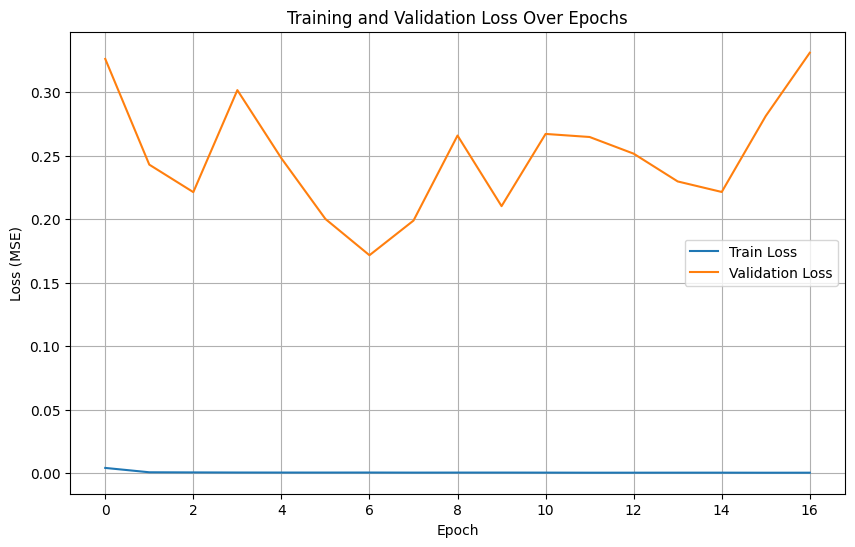

In [47]:
plt.figure(figsize=(10, 6))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["validation_loss"], label="Validation Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

## 10. Évaluation du Modèle

Après l'entraînement, le modèle est évalué sur l'ensemble de test pour mesurer ses performances à l'aide de métriques telles que le score R², l'erreur quadratique moyenne (MSE) et l'erreur absolue moyenne (MAE). Une visualisation des prédictions par rapport aux valeurs réelles est également générée.

### Evaluating the Model

After training, we'll evaluate the model's performance on the unseen test set and calculate metrics like R² score.

In [48]:
def evaluate_model(model, data_loader, target_scaler):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            outputs = model(features)

            # Inverse scale the predictions and actuals
            predictions.extend(
                target_scaler.inverse_transform(
                    outputs.cpu().numpy().reshape(-1, 1)
                ).flatten()
            )
            actuals.extend(
                target_scaler.inverse_transform(
                    targets.cpu().numpy().reshape(-1, 1)
                ).flatten()
            )
    return np.array(predictions), np.array(actuals)

test_predictions, test_actuals = evaluate_model(
    model,
    test_loader,
    target_scaler
)

r2 = r2_score(test_actuals, test_predictions)
mse = mean_squared_error(test_actuals, test_predictions)
mae = mean_absolute_error(test_actuals, test_predictions)

print(f"Test R² Score: {r2:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test R² Score: -9.2009
Test MSE: 28925.4688
Test MAE: 161.3715


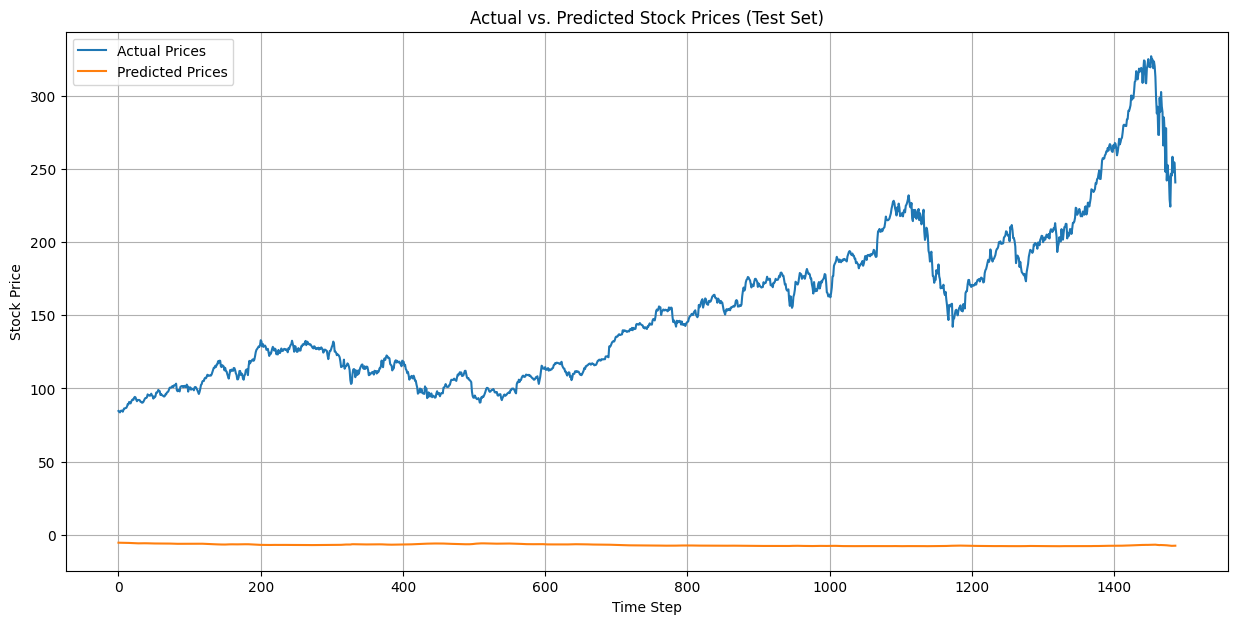

In [49]:
plt.figure(figsize=(15, 7))
plt.plot(test_actuals, label="Actual Prices")
plt.plot(test_predictions, label="Predicted Prices")
plt.title("Actual vs. Predicted Stock Prices (Test Set)")
plt.xlabel("Time Step")
plt.ylabel("Stock Price")
plt.legend()
plt.grid(True)
plt.show()

## 11. Sauvegarde du Modèle et du Scaler

Enfin, le modèle entraîné et l'objet `target_scaler` sont sauvegardés pour une utilisation future, permettant de recharger le modèle sans avoir à le ré-entraîner.

### Saving the Model and Scaler

Finally, we'll save the trained model and the target scaler for future use.

In [50]:
# Save the target_scaler
joblib.dump(target_scaler, "target_scaler.pkl")
print("target_scaler saved as target_scaler.pkl")

# Save the trained model
torch.save(model.state_dict(), "stock_predictor_model.pt")
print("Trained model saved as stock_predictor_model.pt")

target_scaler saved as target_scaler.pkl
Trained model saved as stock_predictor_model.pt


In [53]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

## 9. Entraînement du Modèle

Cette section contient la boucle d'entraînement qui itère sur les époques, calcule la perte d'entraînement et de validation, et implémente l'arrêt précoce pour éviter le surapprentissage.